# Detecção e Contagem de Colônias — Dataset CNPEM

Este notebook implementa o pipeline clássico de visão computacional para
**detecção e contagem de colônias** bacterianas em imagens de placas de Petri,
com base no método descrito por Chiang et al. (2014), utilizando Transformada
de Distância e o algoritmo Watershed para separar colônias sobrepostas.

Este notebook consome as imagens já processadas pela etapa de pré-processamento
(`1_preprocessamento_imagens.ipynb`), localizadas em `dataset-cnpem/crop_circles`,
ou, alternativamente, as imagens originais em `dataset-cnpem/images`, dependendo
de qual conjunto for utilizado na avaliação.

Além de avaliar a precisão do algoritmo, este notebook investiga um argumento
central deste trabalho: a contagem manual de colônias é uma tarefa
repetitiva e mentalmente custosa, especialmente em placas muito povoadas ou
com colônias próximas entre si, o que a torna sujeita a fadiga do analista e
a inconsistências entre diferentes contagens da mesma placa. Para investigar
isso, a seção 3 compara não apenas o algoritmo contra uma contagem humana,
mas duas contagens humanas independentes entre si (`staff`, a contagem
original do analista, e `cvat`, uma recontagem posterior mais cuidadosa usando a ferramenta de segmentação do *CVAT-computer vision annotation tool*),
antes de comparar o algoritmo contra ambas. O objetivo é verificar se o erro
do método automático é compatível com a própria variabilidade observada
entre contadores humanos, o que reforçaria o uso de visão computacional
como uma alternativa mais consistente e reprodutível à contagem manual.

## Estrutura deste notebook

1. Configuração do ambiente (caminhos reprodutíveis)
2. Função principal de detecção e contagem de colônias
3. Avaliação em lote: algoritmo vs. contagem humana (staff e CVAT)
   - 3.1 Divergência entre as duas contagens humanas (staff vs. cvat)
   - 3.2 Algoritmo vs. staff e vs. cvat
   - 3.3 Placas com maior divergência entre staff e cvat
   - 3.4 Gráficos comparativos
4. Execução em uma única imagem de exemplo
5. Visualização do resultado da detecção


## 1. Configuração do ambiente

Definição centralizada dos caminhos utilizados ao longo do notebook, de forma
a manter a execução reprodutível em qualquer ambiente (não exclusivamente no
Google Colab).

- `DATASET_ROOT`: pasta raiz do dataset CNPEM, onde se encontra o arquivo
  `dataset_cfu_cvat.csv`, contendo a contagem original do analista (`staff`)
  e a recontagem feita posteriormente via CVAT (`cvat`) para cada imagem.
- `IMAGES_DIR`: pasta com as imagens originais (`dataset-cnpem/images`).
- `CROP_CIRCLES_DIR`: pasta com as imagens já recortadas/pré-processadas
  (`dataset-cnpem/crop_circles`), gerada pelo notebook de pré-processamento.


In [26]:
import os

DATASET_ROOT = os.getcwd() # Diretório atual onde o script está sendo executado
IMAGES_DIR = os.path.join(DATASET_ROOT, "../data/raw")
CROP_CIRCLES_DIR = os.path.join(DATASET_ROOT, "../data/processed")

print(f"Raiz do dataset: {DATASET_ROOT}")
print(f"Imagens originais: {IMAGES_DIR}")
print(f"Imagens pré-processadas (crop): {CROP_CIRCLES_DIR}")


Raiz do dataset: /Users/leonardorafaelpires/Personal/unicamp/pattern-recognition-2026/IA901-2026S1/projetos/pattern-recognition-in-petri-dishes/notebooks
Imagens originais: /Users/leonardorafaelpires/Personal/unicamp/pattern-recognition-2026/IA901-2026S1/projetos/pattern-recognition-in-petri-dishes/notebooks/../data/raw
Imagens pré-processadas (crop): /Users/leonardorafaelpires/Personal/unicamp/pattern-recognition-2026/IA901-2026S1/projetos/pattern-recognition-in-petri-dishes/notebooks/../data/processed


## 2. Função de detecção e contagem de colônias

A função `contar_colonias` implementa o pipeline completo de visão
computacional clássica para contar colônias em uma imagem de placa de Petri.
As etapas internas do algoritmo são:

1. **Carregamento da imagem** a partir do caminho informado.
2. **Padronização de tamanho**: a imagem é redimensionada para uma largura
   fixa de 800 pixels, mantendo a proporção original, garantindo consistência
   entre imagens de resoluções diferentes.
3. **Detecção dinâmica da placa de Petri** usando a Transformada de Hough
   para círculos (`HoughCircles`). Caso nenhuma placa seja detectada
   automaticamente, uma máscara central padrão é utilizada como fallback.
4. **Extração das colônias via Black-Hat**: uma operação morfológica que
   realça estruturas escuras (as colônias) sobre um fundo mais claro (o ágar),
   restrita à área da placa via máscara.
5. **Binarização (threshold)** da imagem realçada, seguida de uma limpeza
   morfológica leve para remover ruídos pequenos.
6. **Separação de colônias sobrepostas**, via Transformada de Distância +
   algoritmo Watershed (inspirado na Seção 3.2.2 do artigo de referência):
   - identificação da região de fundo certo (`sure_bg`);
   - cálculo da Transformada de Distância para encontrar os centros prováveis
     de cada colônia (`sure_fg`);
   - identificação das regiões de fronteira desconhecidas entre colônias
     próximas;
   - rotulagem dos marcadores e aplicação do Watershed para separar
     individualmente colônias que estejam encostadas.
7. **Contagem final dos marcadores segmentados**, com um filtro de área
   mínima para descartar ruídos residuais, e desenho do contorno de cada
   colônia detectada na imagem de resultado.

A função retorna: a contagem de colônias, a imagem padronizada, a máscara
binária limpa, e a imagem final com as colônias marcadas.


In [11]:
!pip install opencv-python pandas matplotlib scikit-learn --quiet


[notice] A new release of pip is available: 23.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [33]:
import cv2
import numpy as np

from sklearn.decomposition import PCA
def pca_grayscale(image):
    # 1. Carregar a imagem (OpenCV carrega em BGR, mudamos para RGB)
    # img = cv2.imread(image_path)
    # img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_rgb = image

    # 2. Redimensionar a imagem para uma matriz de pixels (N_pixels, 3 canais)
    # Cada linha será um pixel e as colunas serão R, G e B
    height, width, channels = img_rgb.shape
    pixels = img_rgb.reshape(-1, channels)

    # 3. Aplicar o PCA para reduzir de 3 canais para 1
    # n_components=1 significa que queremos apenas a primeira componente principal
    pca = PCA(n_components=1)
    img_pca = pca.fit_transform(pixels)

    # 4. O PCA pode retornar valores fora do intervalo [0, 255] e até negativos.
    # Precisamos normalizar de volta para o padrão de imagem de 8 bits.
    img_pca_min = img_pca.min()
    img_pca_max = img_pca.max()

    if img_pca_max - img_pca_min != 0:
        img_normalized = (
            (img_pca - img_pca_min) / (img_pca_max - img_pca_min) * 255
        )
    else:
        img_normalized = img_pca

    # 5. Voltar para o formato original da imagem (Height, Width)
    gray_pca = img_normalized.reshape(height, width).astype(np.uint8)

    return gray_pca

def contar_colonias(caminho_imagem, sensibilidade_thresh=12, min_dist_centro=2.0):
    image = cv2.imread(caminho_imagem)
    if image is None:
        print("Erro ao carregar a imagem. Verifique o caminho.")
        return None, None, None, None

    largura_desejada = 800
    proporcao = largura_desejada / image.shape[1]
    altura_desejada = int(image.shape[0] * proporcao)
    image = cv2.resize(image, (largura_desejada, altura_desejada))

    imagem_resultado = image.copy()
    gray = pca_grayscale(image)

    blur_placa = cv2.medianBlur(gray, 21)
    circulos = cv2.HoughCircles(blur_placa, cv2.HOUGH_GRADIENT, dp=1.2, minDist=100,
                                param1=50, param2=30, minRadius=200, maxRadius=400)

    mask = np.zeros_like(gray)

    if circulos is not None:
        circulos = np.round(circulos[0, :]).astype("int")
        cx, cy, r = circulos[0]
        cv2.circle(mask, (cx, cy), int(r * 0.86), 255, -1)
    else:
        print("Aviso: Placa não detectada automaticamente. Usando máscara central.")
        cv2.circle(mask, (largura_desejada//2, altura_desejada//2), int(largura_desejada * 0.4), 255, -1)

    kernel_bh = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (35, 35))
    blackhat = cv2.morphologyEx(gray, cv2.MORPH_BLACKHAT, kernel_bh)

    blackhat_masked = cv2.bitwise_and(blackhat, blackhat, mask=mask)

    _, thresh = cv2.threshold(blackhat_masked, sensibilidade_thresh, 255, cv2.THRESH_BINARY)

    kernel_clean = np.ones((3,3), np.uint8)
    thresh_limpo = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel_clean)

    sure_bg = cv2.dilate(thresh_limpo, kernel_clean, iterations=2)

    dist_transform = cv2.distanceTransform(thresh_limpo, cv2.DIST_L2, 5)

    _, sure_fg = cv2.threshold(dist_transform, min_dist_centro, 255, cv2.THRESH_BINARY)
    sure_fg = np.uint8(sure_fg)

    unknown = cv2.subtract(sure_bg, sure_fg)

    num_labels, markers = cv2.connectedComponents(sure_fg)

    markers = markers + 1

    markers[unknown == 255] = 0

    markers = cv2.watershed(image, markers)

    colony_count = 0
    unique_markers = np.unique(markers)

    for label in unique_markers:
        if label <= 1:
            continue

        label_mask = np.uint8(markers == label) * 255

        contours, _ = cv2.findContours(label_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

        if len(contours) > 0:
            contour = contours[0]
            area = cv2.contourArea(contour)

            if area > 8:
                colony_count += 1

                (x, y), radius_c = cv2.minEnclosingCircle(contour)
                cv2.circle(imagem_resultado, (int(x), int(y)), int(radius_c) + 3, (0, 255, 0), 2)

    return colony_count, image, thresh_limpo, imagem_resultado

## 3. Avaliação em lote: algoritmo vs. contagem humana (staff e CVAT)

Nesta etapa, o pipeline de contagem é aplicado a todas as imagens listadas no
arquivo `dataset_cfu_cvat.csv`. Diferentemente da avaliação original (que
comparava o algoritmo contra um único ground truth), este conjunto de dados
traz **duas contagens humanas independentes** para a mesma imagem:

- **`staff`**: contagem original, feita por um analista durante a rotina do
  laboratório.
- **`cvat`**: recontagem feita posteriormente, com apoio de uma ferramenta de
  anotação visual (CVAT), permitindo conferência mais cuidadosa,
  colônia a colônia, sobre a própria imagem.

A existência de duas contagens humanas distintas para a mesma placa é, por si
só, um dado relevante: contar colônias manualmente é uma tarefa repetitiva e
mentalmente exaustiva, sobretudo em placas com dezenas ou centenas de
colônias próximas umas das outras. Esse tipo de tarefa está sujeito a fadiga
do analista, perda de contagem em colônias muito próximas ou sobrepostas, e
viés de arredondamento em placas muito povoadas — fatores que podem introduzir
ruído nos dados usados posteriormente em uma pesquisa. Por isso, antes mesmo
de avaliar o algoritmo, comparamos **`staff` contra `cvat`**, para quantificar
o quanto duas contagens humanas da mesma placa podem divergir entre si.
Em seguida, avaliamos o algoritmo de visão computacional contra **ambas** as
referências humanas (`staff` e `cvat`), permitindo comparar diretamente se o
método automático se aproxima mais de uma ou de outra, e se o seu erro é da
mesma ordem de grandeza do erro observado entre dois contadores humanos.

Resumo do processo:

1. Leitura do arquivo `dataset_cfu_cvat.csv` a partir de `DATASET_ROOT`,
   contendo as colunas `image_file`, `staff` e `cvat`.
2. Execução da função `contar_colonias` para cada imagem do dataset,
   acumulando as predições do algoritmo em `y_pred`.
3. Cálculo das métricas de erro (MAE, RMSE e MAPE) para três comparações:
   `staff` vs. `cvat`, algoritmo vs. `staff`, e algoritmo vs. `cvat`.
4. Tabela com as placas de maior divergência entre `staff` e `cvat`,
   evidenciando os casos mais custosos para a contagem manual.
5. Gráficos de dispersão separados: (a) `staff` vs. `cvat` e (b) algoritmo
   vs. `cvat`, permitindo a inspeção visual de cada comparação.


In [27]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

path = IMAGES_DIR

dataset_path = os.path.join(path, 'dataset_cfu_cvat.csv')
df = pd.read_csv(dataset_path)

y_pred_list = []

print("Iniciando o processamento das imagens e contagem de colônias...")

for index, row in df.iterrows():
    img_path = os.path.join(IMAGES_DIR, row['image_file'])

    pred_count, image, thresh_limpo, imagem_resultado = contar_colonias(img_path)
    y_pred_list.append(pred_count)

df['y_pred'] = y_pred_list

display(df)

df_valid = df.dropna(subset=['y_pred']).copy()

print(f"\nTotal de placas processadas com sucesso: {len(df_valid)} de {len(df)}")


Iniciando o processamento das imagens e contagem de colônias...


,image_file,staff,cvat,y_pred
0,IMG_0643.jpg,5,5,3
1,IMG_0647.jpg,27,27,23
2,IMG_0650.jpg,164,164,99
3,IMG_0653.jpg,58,58,39
4,IMG_0655.jpg,83,83,73
...,...,...,...,...
89,IMG_0728.jpg,36,35,26
90,IMG_0730.jpg,29,30,25
91,IMG_0733.jpg,66,91,76
92,IMG_0735.jpg,73,72,71



Total de placas processadas com sucesso: 94 de 94


## 3.1 Divergência entre as duas contagens humanas (`staff` vs. `cvat`)

Antes de avaliar o algoritmo, medimos o quanto a contagem original do
analista (`staff`) diverge da recontagem mais cuidadosa (`cvat`) para a
mesma imagem. Usamos as mesmas três métricas adotadas ao longo deste
notebook — MAE, RMSE e MAPE — só que aplicadas entre as duas colunas
humanas, em vez de entre uma contagem humana e a predição do algoritmo.

Esse número é o ponto de partida do argumento central desta avaliação: se
duas contagens feitas por pessoas, da mesma placa, já apresentam uma
divergência relevante entre si, isso evidencia que a contagem manual está
sujeita a uma margem de erro própria, decorrente do esforço cognitivo
exigido pela tarefa — e não de uma falha pontual de qualquer um dos dois
métodos. O MAPE entre `staff` e `cvat` é calculado apenas sobre placas em
que `cvat` é maior que zero, pelo mesmo motivo de indefinição matemática já
discutido anteriormente neste notebook.


In [28]:
mae_staff_cvat = mean_absolute_error(df_valid['cvat'], df_valid['staff'])
rmse_staff_cvat = np.sqrt(mean_squared_error(df_valid['cvat'], df_valid['staff']))

df_staff_cvat_mape = df_valid[df_valid['cvat'] > 0]
mape_staff_cvat = mean_absolute_percentage_error(df_staff_cvat_mape['cvat'], df_staff_cvat_mape['staff'])

print("-" * 40)
print(" DIVERGÊNCIA ENTRE CONTAGENS HUMANAS (staff vs. cvat) ")
print("-" * 40)
print(f"MAE  (Erro Médio Absoluto): {mae_staff_cvat:.2f} colônias")
print(f"RMSE (Raiz do Erro Quadrático Médio): {rmse_staff_cvat:.2f} colônias")
print(f"MAPE (Erro Percentual Absoluto Médio): {mape_staff_cvat * 100:.2f}%")
print("-" * 40)


----------------------------------------
 DIVERGÊNCIA ENTRE CONTAGENS HUMANAS (staff vs. cvat) 
----------------------------------------
MAE  (Erro Médio Absoluto): 13.41 colônias
RMSE (Raiz do Erro Quadrático Médio): 43.23 colônias
MAPE (Erro Percentual Absoluto Médio): 14.05%
----------------------------------------


## 3.2 Algoritmo de visão computacional vs. `staff` e vs. `cvat`

Com a divergência humana já quantificada, avaliamos agora o algoritmo de
visão computacional contra cada uma das duas referências, separadamente.
Como não há, estritamente, uma única contagem "verdadeira" entre as duas
(`staff` e `cvat` são ambas estimativas humanas da mesma quantidade real de
colônias), comparamos o algoritmo contra as duas, lado a lado: isso permite
verificar se a discrepância do algoritmo em relação às pessoas é da mesma
ordem de grandeza da discrepância que as próprias pessoas têm entre si
(calculada na seção 3.1), o que reforçaria que parte do "erro" do algoritmo
é, na verdade, ambiguidade inerente à tarefa de contagem visual de colônias
muito numerosas ou muito próximas, e não uma falha exclusiva do método
automático.


In [34]:
resultados = {}

for nome_referencia in ['staff', 'cvat']:
    mae_ref = mean_absolute_error(df_valid[nome_referencia], df_valid['y_pred'])
    rmse_ref = np.sqrt(mean_squared_error(df_valid[nome_referencia], df_valid['y_pred']))

    df_ref_mape = df_valid[df_valid[nome_referencia] > 0]
    mape_ref = mean_absolute_percentage_error(df_ref_mape[nome_referencia], df_ref_mape['y_pred'])

    resultados[nome_referencia] = {'MAE': mae_ref, 'RMSE': rmse_ref, 'MAPE': mape_ref}

    print("-" * 40)
    print(f" ALGORITMO vs. {nome_referencia.upper()} ")
    print("-" * 40)
    print(f"MAE  (Erro Médio Absoluto): {mae_ref:.2f} colônias")
    print(f"RMSE (Raiz do Erro Quadrático Médio): {rmse_ref:.2f} colônias")
    print(f"MAPE (Erro Percentual Absoluto Médio): {mape_ref * 100:.2f}%")
    print("-" * 40)
    print()

resumo_comparativo = pd.DataFrame(resultados).T
resumo_comparativo.loc['staff_vs_cvat'] = {'MAE': mae_staff_cvat, 'RMSE': rmse_staff_cvat, 'MAPE': mape_staff_cvat}
display(resumo_comparativo)


----------------------------------------
 ALGORITMO vs. STAFF 
----------------------------------------
MAE  (Erro Médio Absoluto): 19.20 colônias
RMSE (Raiz do Erro Quadrático Médio): 34.93 colônias
MAPE (Erro Percentual Absoluto Médio): 105.49%
----------------------------------------

----------------------------------------
 ALGORITMO vs. CVAT 
----------------------------------------
MAE  (Erro Médio Absoluto): 27.66 colônias
RMSE (Raiz do Erro Quadrático Médio): 60.59 colônias
MAPE (Erro Percentual Absoluto Médio): 131.37%
----------------------------------------



,MAE,RMSE,MAPE
staff,19.202128,34.927128,1.054910
cvat,27.659574,60.587022,1.313727
staff_vs_cvat,13.414894,43.226396,0.140485


## 3.3 Placas com maior divergência entre `staff` e `cvat`

A tabela abaixo lista as placas em que a diferença absoluta entre `staff` e
`cvat` foi maior, ordenadas da maior para a menor divergência. Essas são,
justamente, as placas que melhor ilustram o custo cognitivo da contagem
manual: tendem a ser concentradas em imagens com um número elevado de
colônias, ou com colônias muito próximas entre si, cenário em que a chance
de um analista perder a contagem ou contar uma colônia duas vezes aumenta
consideravelmente.


In [30]:
df_valid['diff_staff_cvat'] = (df_valid['staff'] - df_valid['cvat']).abs()

tabela_divergencias = df_valid[['image_file', 'staff', 'cvat', 'diff_staff_cvat']] \
    .sort_values('diff_staff_cvat', ascending=False)

display(tabela_divergencias)


,image_file,staff,cvat,diff_staff_cvat
13,IMG_0529.jpg,260,551,291
27,IMG_0561.jpg,9,174,165
14,IMG_0531.jpg,170,290,120
28,IMG_0563.jpg,9,118,109
9,10_3_i.jpg,42,145,103
...,...,...,...,...
55,IMG_0624.jpg,1,1,0
57,IMG_0628.jpg,1,1,0
58,IMG_0631.jpg,1,1,0
59,IMG_0633.jpg,0,0,0


## 3.4 Gráficos comparativos

Por fim, dois gráficos de dispersão são gerados separadamente:

1. **`staff` vs. `cvat`**: evidencia visualmente a divergência entre as duas
   contagens humanas da mesma placa.
2. **Algoritmo vs. `cvat`**: evidencia visualmente a proximidade entre a
   predição automática e a recontagem mais cuidadosa, servindo de referência
   para comparação direta com o primeiro gráfico.

Em ambos os gráficos, uma linha cinza vertical conecta os dois valores
comparados para cada imagem, facilitando a leitura da magnitude do erro
placa a placa, no mesmo estilo de visualização já utilizado neste notebook.


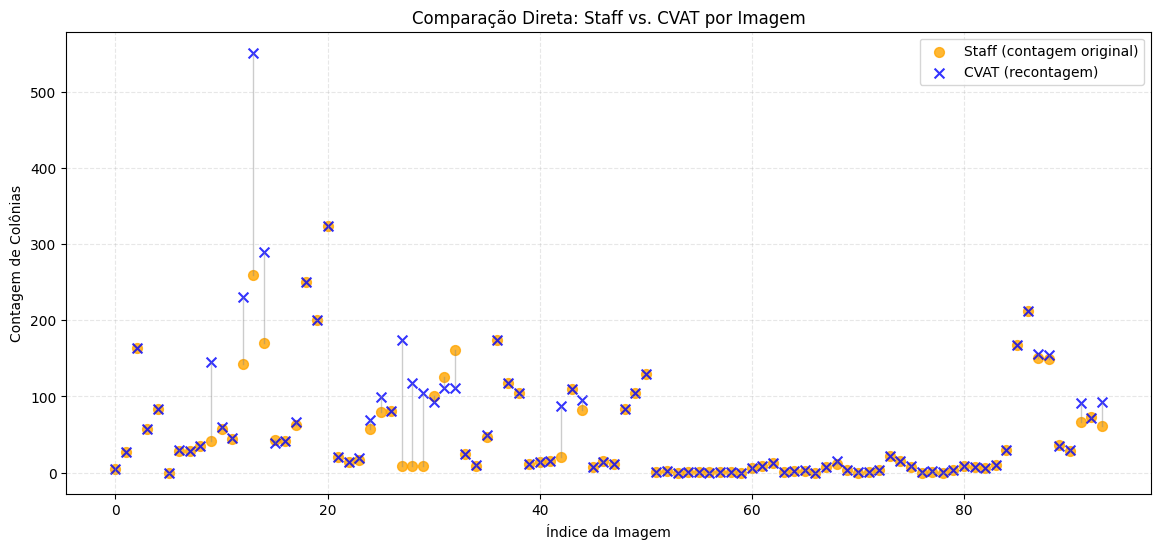

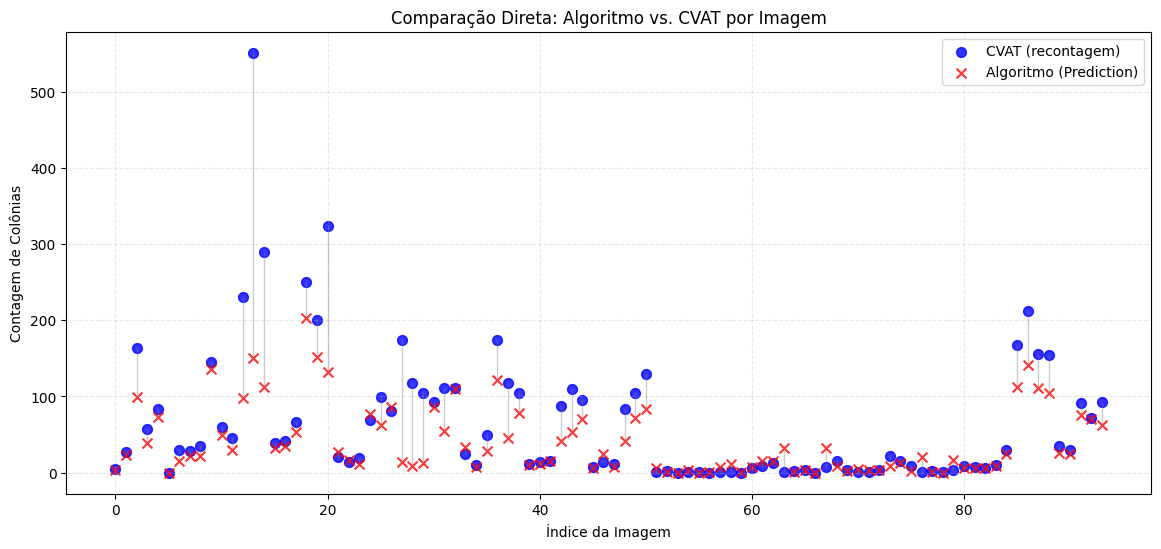

In [31]:
plt.figure(figsize=(14, 6))

for idx in df_valid.index:
    plt.plot([idx, idx], [df_valid.loc[idx, 'staff'], df_valid.loc[idx, 'cvat']],
             color='gray', linestyle='-', alpha=0.4, linewidth=1)

plt.scatter(df_valid.index, df_valid['staff'], alpha=0.8, color='orange', marker='o', s=50, label='Staff (contagem original)')
plt.scatter(df_valid.index, df_valid['cvat'], alpha=0.8, color='blue', marker='x', s=50, label='CVAT (recontagem)')

plt.title('Comparação Direta: Staff vs. CVAT por Imagem')
plt.xlabel('Índice da Imagem')
plt.ylabel('Contagem de Colônias')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()

plt.figure(figsize=(14, 6))

for idx in df_valid.index:
    plt.plot([idx, idx], [df_valid.loc[idx, 'cvat'], df_valid.loc[idx, 'y_pred']],
             color='gray', linestyle='-', alpha=0.4, linewidth=1)

plt.scatter(df_valid.index, df_valid['cvat'], alpha=0.8, color='blue', marker='o', s=50, label='CVAT (recontagem)')
plt.scatter(df_valid.index, df_valid['y_pred'], alpha=0.8, color='red', marker='x', s=50, label='Algoritmo (Prediction)')

plt.title('Comparação Direta: Algoritmo vs. CVAT por Imagem')
plt.xlabel('Índice da Imagem')
plt.ylabel('Contagem de Colônias')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()


## 4. Execução em uma única imagem de exemplo

Para fins de inspeção visual e depuração do pipeline, esta célula executa a
função `contar_colonias` isoladamente sobre uma única imagem de exemplo
(`IMG_0568.jpg`), localizada em `IMAGES_DIR`.


In [39]:
colony_count, image, thresh_limpo, imagem_resultado = contar_colonias(os.path.join(IMAGES_DIR, "IMG_0636.jpg"))

## 5. Visualização do resultado da detecção

Esta célula exibe lado a lado três imagens, permitindo avaliar visualmente
cada etapa do pipeline para a imagem de exemplo processada acima:

1. **Imagem Padronizada (800px)**: a imagem original já redimensionada.
2. **Máscara Alinhada Automaticamente**: a máscara binária limpa, resultado
   da segmentação das colônias (Black-Hat + threshold + limpeza morfológica).
3. **Detecção**: a imagem final com cada colônia individualmente
   identificada e contornada em verde, junto com o total de colônias
   contadas.


Total de colônias contadas: 8


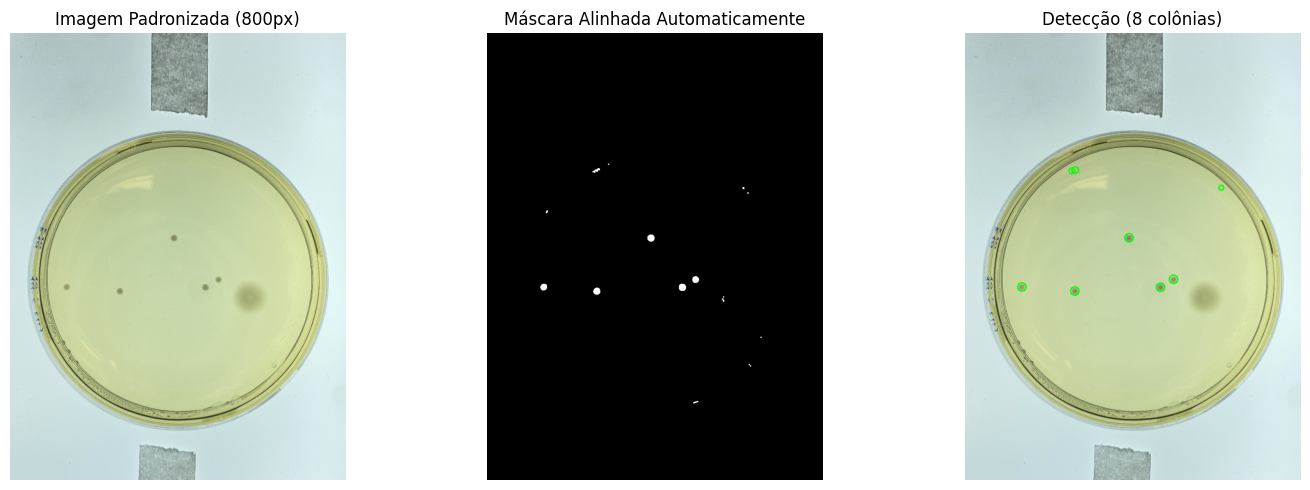

In [40]:
print(f"Total de colônias contadas: {colony_count}")
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title('Imagem Padronizada (800px)')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(thresh_limpo, cmap='gray')
plt.title('Máscara Alinhada Automaticamente')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(cv2.cvtColor(imagem_resultado, cv2.COLOR_BGR2RGB))
plt.title(f'Detecção ({colony_count} colônias)')
plt.axis('off')

plt.tight_layout()
plt.show()
